In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
%matplotlib inline

In [7]:
X,y=make_blobs(n_samples=1000,centers=5,n_features=2,random_state=42)

In [8]:
y

array([1, 1, 2, 1, 4, 2, 3, 4, 1, 4, 4, 2, 3, 2, 3, 2, 0, 3, 0, 4, 1, 0,
       3, 2, 0, 1, 0, 3, 4, 3, 1, 3, 4, 3, 0, 2, 4, 4, 4, 0, 4, 3, 3, 2,
       3, 2, 1, 1, 0, 2, 1, 3, 2, 0, 0, 0, 0, 2, 2, 0, 1, 3, 2, 4, 2, 1,
       3, 3, 1, 1, 3, 2, 1, 2, 3, 0, 3, 1, 1, 3, 0, 1, 2, 2, 3, 1, 0, 4,
       0, 3, 1, 3, 1, 4, 4, 2, 0, 0, 2, 3, 2, 4, 1, 2, 0, 1, 0, 2, 4, 0,
       0, 1, 2, 2, 3, 0, 3, 2, 0, 4, 2, 0, 2, 2, 2, 2, 3, 2, 0, 1, 1, 3,
       1, 4, 2, 4, 1, 4, 0, 3, 2, 0, 1, 0, 1, 1, 2, 1, 1, 4, 3, 2, 1, 1,
       0, 1, 1, 0, 3, 1, 3, 1, 3, 0, 3, 1, 4, 3, 0, 1, 2, 0, 0, 2, 4, 2,
       3, 2, 1, 4, 1, 0, 1, 3, 4, 4, 1, 2, 3, 0, 3, 0, 1, 4, 1, 0, 4, 2,
       0, 1, 2, 3, 2, 2, 3, 4, 4, 0, 4, 1, 0, 3, 3, 4, 1, 2, 2, 2, 3, 4,
       2, 2, 0, 2, 0, 4, 2, 4, 1, 1, 0, 1, 0, 1, 1, 3, 0, 0, 3, 1, 4, 3,
       2, 4, 2, 2, 2, 2, 3, 4, 2, 2, 4, 1, 4, 0, 3, 1, 1, 0, 1, 4, 1, 3,
       1, 3, 3, 3, 2, 2, 1, 1, 3, 4, 0, 4, 2, 0, 3, 4, 4, 2, 1, 4, 2, 3,
       1, 1, 1, 0, 4, 0, 3, 4, 1, 3, 4, 4, 0, 4, 3,

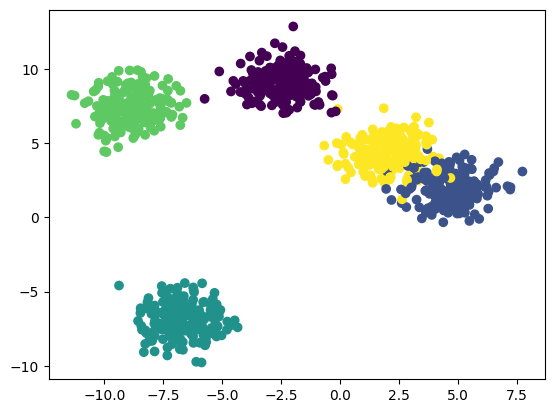

In [9]:
plt.scatter(X[:,0],X[:,1],c=y)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [17]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [18]:
from sklearn.cluster import KMeans


In [20]:
#Elbow Method
interia=[]
for i in range(1,11): 
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_train_scaled)
    interia.append(kmeans.inertia_)

In [21]:
interia

[1599.9999999999977,
 844.034240012728,
 215.02507843057649,
 88.92214845035993,
 52.9596525909117,
 48.65388973795114,
 44.875669922490495,
 41.85177130281525,
 38.02110284123688,
 34.92178019115281]

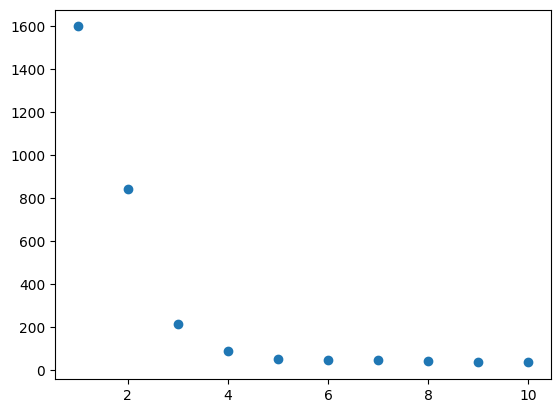

In [23]:
plt.scatter(range(1,11),interia)

In [24]:
!pip install kneed

In [25]:
from kneed import KneeLocator

In [26]:
kl=KneeLocator(range(1,11),interia,curve="convex",direction="decreasing")

In [27]:
kl.elbow

np.int64(3)

In [28]:
##Silhoutte Score
from sklearn.metrics import silhouette_score

In [30]:
silhouette_coefficients=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)